<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Trabajo practico 2

### Custom embedddings con Gensim

### Ceballos,Luciano
### a2110
- Crear sus propios vectores con Gensim basado en lo visto en clase con otro dataset.
- Probar términos de interés y explicar similitudes en el espacio de embeddings (sacar conclusiones entre palabras similitudes y diferencias).
- Graficarlos.
- Obtener conclusiones.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from itertools import chain
import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
from sklearn.manifold import TSNE
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

### Datos
Dataset canciones de bandas de habla inglesa.

In [3]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [4]:
# Posibles bandas
os.listdir("./songs_dataset/")

['kanye.txt',
 'rihanna.txt',
 'jimi-hendrix.txt',
 'disney.txt',
 'johnny-cash.txt',
 'al-green.txt',
 'lorde.txt',
 'eminem.txt',
 'bob-dylan.txt',
 'dr-seuss.txt',
 'dj-khaled.txt',
 'Kanye_West.txt',
 'nickelback.txt',
 'missy-elliott.txt',
 'cake.txt',
 'britney-spears.txt',
 'prince.txt',
 'bjork.txt',
 'adele.txt',
 'bieber.txt',
 'drake.txt',
 'alicia-keys.txt',
 'kanye-west.txt',
 'michael-jackson.txt',
 'ludacris.txt',
 'nicki-minaj.txt',
 'paul-simon.txt',
 'nirvana.txt',
 'lin-manuel-miranda.txt',
 'patti-smith.txt',
 'beatles.txt',
 'nursery_rhymes.txt',
 'lady-gaga.txt',
 'radiohead.txt',
 'dolly-parton.txt',
 'notorious_big.txt',
 'amy-winehouse.txt',
 'dickinson.txt',
 'joni-mitchell.txt',
 'lil-wayne.txt',
 'bob-marley.txt',
 'bruno-mars.txt',
 'r-kelly.txt',
 'notorious-big.txt',
 'Lil_Wayne.txt',
 'leonard-cohen.txt',
 'bruce-springsteen.txt',
 'janisjoplin.txt',
 'blink-182.txt']

In [5]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/eminem.txt', sep='/n', header=None)
df.head()

,0
0,"Look, I was gonna go easy on you and not to hu..."
1,But I'm only going to get this one chance
2,"Something's wrong, I can feel it (Six minutes,..."
3,"Just a feeling I've got, like something's abou..."
4,"If that means, what I think it means, we're in..."


In [6]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 6812


In [7]:
df = df.rename(columns={0:'texto'})

----

In [8]:
# Callback personalizado para monitorear el entrenamiento
class LossCallback(CallbackAny2Vec):
    """Callback para imprimir la pérdida después de cada época"""
    def __init__(self):
        self.epoch = 0
        self.losses = []

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print(f'Loss después de época {self.epoch}: {loss:.4f}')
        else:
            epoch_loss = loss - self.loss_previous_step
            print(f'Loss después de época {self.epoch}: {epoch_loss:.4f}')
            self.losses.append(epoch_loss)
        self.epoch += 1
        self.loss_previous_step = loss

### Preprocesamiento:

In [9]:
sentence_tokens = []

for texto in df['texto']:
    # Convertir a minúsculas y eliminar caracteres especiales
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)

    # Tokenizar usando split simple
    tokens = texto.split()

    if len(tokens) > 0:
      sentence_tokens.append(tokens)

print(f" Documentos procesados: {len(sentence_tokens)}")
print(f" Ejemplo de tokens: {sentence_tokens[0][:10]}")

 Documentos procesados: 6812
 Ejemplo de tokens: ['look', 'i', 'was', 'gonna', 'go', 'easy', 'on', 'you', 'and', 'not']


In [10]:
# Entrenar modelo Word2Vec
flattened_tokens = list(chain.from_iterable(sentence_tokens))
df_vocab = pd.Series(flattened_tokens)
conteo = df_vocab.value_counts()
for i in [1,2,3,4,5]:
  corte = i # nro de repeticion de palabras para considerarla
  palabras_a_eliminar = conteo[conteo < corte].count()
  print(f"Con min_count={corte} se van a eliminar {palabras_a_eliminar} palabras del vocabulario.")

Con min_count=1 se van a eliminar 0 palabras del vocabulario.
Con min_count=2 se van a eliminar 3013 palabras del vocabulario.
Con min_count=3 se van a eliminar 4026 palabras del vocabulario.
Con min_count=4 se van a eliminar 4476 palabras del vocabulario.
Con min_count=5 se van a eliminar 4739 palabras del vocabulario.


Se va a entrenar con **min_count=3**, quedando 2031 palabras (33% del vocabulario original).

### Entrenamiento del modelo:

In [11]:
def entrenar_word2vec(sentence_tokens,
                      vector_size=100,
                      window=5,
                      min_count=1,
                      sg=1,
                      epochs=50):
    """
    Entrena un modelo Word2Vec con los parámetros especificados

    Args:
        sentence_tokens: Lista de listas de tokens
        vector_size: Dimensión de los vectores
        window: Tamaño de la ventana de contexto
        min_count: Frecuencia mínima de palabras
        sg: 0 para CBOW, 1 para Skip-gram
        epochs: Número de épocas de entrenamiento

    Returns:
        Modelo Word2Vec entrenado
    """
    print("\n" + "="*60)
    print("Entrenando el modelo Word2Vec...")
    print("="*60)

    # Crear el modelo
    modelo = Word2Vec(
        min_count=min_count,
        window=window,
        vector_size=vector_size,
        negative=20,
        workers=4,
        sg=sg,
        seed=42
    )

    # Construir vocabulario
    modelo.build_vocab(sentence_tokens)
    print(f" Tamaño del vocabulario: {len(modelo.wv.index_to_key)} palabras")

    # Callback para monitorear entrenamiento
    callback = LossCallback()

    # Entrenar
    modelo.train(
        sentence_tokens,
        total_examples=modelo.corpus_count,
        epochs=epochs,
        compute_loss=True,
        callbacks=[callback]
    )

    return modelo, callback.losses

In [12]:
    # Entrenar modelo Word2Vec
    modelo, losses = entrenar_word2vec(
        sentence_tokens,
        vector_size=70,
        window=5,
        min_count=3,
        sg=1,  # Skip-gram
        epochs=100
    )


Entrenando el modelo Word2Vec...
 Tamaño del vocabulario: 2031 palabras
Loss después de época 0: 287051.5625
Loss después de época 1: 190735.4375
Loss después de época 2: 187701.6250
Loss después de época 3: 184145.5625
Loss después de época 4: 176576.6875
Loss después de época 5: 160992.5000
Loss después de época 6: 157067.7500
Loss después de época 7: 152853.3750
Loss después de época 8: 153064.0000
Loss después de época 9: 145656.2500
Loss después de época 10: 145338.2500
Loss después de época 11: 137130.6250
Loss después de época 12: 134585.1250
Loss después de época 13: 129675.7500
Loss después de época 14: 131080.2500
Loss después de época 15: 128218.7500
Loss después de época 16: 133748.2500
Loss después de época 17: 126997.0000
Loss después de época 18: 127708.7500
Loss después de época 19: 121940.2500
Loss después de época 20: 131512.0000
Loss después de época 21: 124394.5000
Loss después de época 22: 127211.5000
Loss después de época 23: 127440.2500
Loss después de época 24:

In [13]:
print("\n" + "="*60)
print("Detalles del modelo:")
print("="*60)

# Estadisticas del modelo
print("\n Estadisticas del modelo:")
print(f"   - Tamaño del vocabulario: {len(modelo.wv.index_to_key)} palabras")
print(f"   - Dimensión de vectores: {modelo.wv.vector_size}")
print(f"   - Documentos procesados: {modelo.corpus_count}")


Detalles del modelo:

 Estadisticas del modelo:
   - Tamaño del vocabulario: 2031 palabras
   - Dimensión de vectores: 70
   - Documentos procesados: 6812


### Análisis de similitudes

Primero se definen ciertas palabras para calcular similitudes:

In [14]:
# Palabras de interés para análisis
palabras_interes = [
     'city','plane', 'food', 'travel','storm','house'
]

# Filtrar palabras que estan en el vocabulario
palabras_interes = [p for p in palabras_interes if p in modelo.wv.index_to_key]

In [15]:
print("Análisis de similitudes entre palabras mediante el especio definido en el embedding")
print("="*60)

resultados = {}

for palabra in palabras_interes:
  if palabra in modelo .wv .index_to_key:
    print(f"\n Analizando: '{palabra}'")
    print("-" * 40)

    # Palabras mas similares
    similares = modelo.wv.most_similar(positive=[palabra], topn=5)
    print(" Palabras más similares:")
    for word, score in similares:
      print(f"   - {word}: {score:.4f}")

    # Palabras menos similares
    diferentes = modelo.wv.most_similar(negative=[palabra], topn=3)
    print(" Palabras menos relacionadas:")
    for word, score in diferentes:
        print(f"   - {word}: {score:.4f}")

    resultados[palabra] = {
                'similares': similares,
                'diferentes': diferentes
            }
  else:
    print(f"\n '{palabra}' no está en el vocabulario")

Análisis de similitudes entre palabras mediante el especio definido en el embedding

 Analizando: 'city'
----------------------------------------
 Palabras más similares:
   - having: 0.6119
   - riding: 0.5982
   - detroit: 0.5890
   - motha: 0.5486
   - belt: 0.5359
 Palabras menos relacionadas:
   - move: 0.1060
   - kfed: 0.0875
   - hush: 0.0756

 Analizando: 'plane'
----------------------------------------
 Palabras más similares:
   - gravity: 0.5795
   - ropes: 0.5602
   - surface: 0.5569
   - couch: 0.5470
   - citys: 0.5465
 Palabras menos relacionadas:
   - outta: 0.0466
   - swear: 0.0324
   - above: 0.0319

 Analizando: 'food'
----------------------------------------
 Palabras más similares:
   - stamps: 0.8164
   - diapers: 0.7079
   - buy: 0.5563
   - family: 0.5248
   - telling: 0.5214
 Palabras menos relacionadas:
   - stay: 0.0971
   - day: 0.0887
   - nothing: 0.0767

 Analizando: 'travel'
----------------------------------------
 Palabras más similares:
   - land: 0

Conclusiones:
- Para la palabra **city** se destacan las cercanias detectadas con **detroit**, ciudad donde se desarrolló el artista, su escenario y un personaje más en sus historias. Que sea una similitud muy alta demuestra que el embedding capturó la identidad central del texto. **Riding** es otra palabra cercana, en la cultura Hip-Hop y en las letras de Eminem , la interacción principal con la ciudad es conducir a través de ella.
- **Plane**: Aca el modelo no está asociando "avión" con "aeropuerto" o "alas", sino con ansiedad, despedidas y el miedo al fracaso. Aquí el modelo cree que un avión (plane) es: Un lugar donde ocurren fugas (escape) y errores (missed), intrínsecamente ligado a la tensión entre volar alto y la gravedad (gravity) que te hace fracasar (choked).
- **Food**: Aqui Comida = Pobreza, Cupones y Responsabilidad Paternal. Coincidente con el duro contexto social que describen las canciones de este autor. Comida según este modelo se relaciona **stamps**, food stamps en ingles significa cupones de alimentos del gobierno. **Diapers** es otra palabra altamente relacionada, representa el dilema planteado en varias de las letras del autor: Comer o comprar pañales para sus hijos. **Buy** y **family** son otras palabras altamente relacionadas y tienen que ver con la necesidad y dificultad de adquirir la comida para su familia.
- **Storm**: Aquí vemos la faceta de Eminem como líder motivacional (álbumes Recovery o The Eminem Show). Eminem usa la "tormenta" como metáfora de las dificultades que él y sus fans atraviesan juntos. La palabra **shine** (brillar/sol) es el antónimo natural. El modelo entiende que **storm** es la oscuridad temporal antes de que llegue el **shine**.
- **House**: Para el modelo, una house (casa) no es un hogar dulce y acogedor. Es un escenario de crimen o un lugar bajo asedio.

### Analogías semanticas



In [ ]:
analogias = [
        {
            'positivos': ['food', 'stamps'],
            'negativos': ['buy'],
            'descripcion': 'food + stamps - buy '
        },
        {
            'positivos': ['thoughts', 'dark'],
            'negativos': [],
            'descripcion': 'thoughts + dark '
        },
        {
            'positivos': ['detroit','riding'],
            'negativos': [],
            'descripcion': 'Contexto de  detroit + riding'
        }
    ]

In [17]:
# Definir algunas analogías para probar
for analogia in analogias:
  try:
    print(f"\n {analogia['descripcion']}")
    resultado = modelo .wv .most_similar(
                positive=analogia['positivos'],
                negative=analogia['negativos'] if analogia['negativos'] else None,
                topn=3
            )
    for palabra, score in resultado:
      print(f"   → {palabra}: {score:.4f}")
  except:
    print(f"    No se pudo calcular esta analogía")


 food + stamps - buy 
   → diapers: 0.6062
   → snaking: 0.4833
   → piano: 0.4822

 thoughts + dark 
   → sitting: 0.5737
   → shining: 0.5653
   → june: 0.5587

 Contexto de  detroit + riding
   → shotgun: 0.7234
   → city: 0.7124
   → 2pac: 0.6770


- **food + stamps - buy**: Tomando el concepto de "cupones de comida" (asistencia social) e intendo restar la acción comercial de "comprar" el resultado es diapers (pañales). Esto se puede interpretar como que el modelo ha encontrado otros artículos de primera necesidad que suelen aparecer en el mismo contexto socioeconómico que los cupones de comida.
- **Thoughts + dark**: Por un lado **confusing** es una relación semántica directa, los pensamientos oscuros confunden. Por otro lado **shining** indica que para el modelo las palabras shining y dark, son vectores matemáticamente cercanos aunque sean opuestos en significado.
- **Detroit + riding**: Al sumar el vector de un lugar específico (Detroit) con una acción de desplazamiento (riding), el modelo generaliza hacia el entorno donde ocurre esa acción. Es decir, el "promedio" de manejar por Detroit nos sitúa en el concepto general de ciudad, por eso la asociacion con la palabra **city**. Por otro lado para la palabra **shotgun**, el modelo ha aprendido que la probabilidad de que la palabra shotgun aparezca cerca de riding es altísima. Aunque se le sumó Detroit, la fuerza gravitacional del bigrama "riding + shotgun" es tan fuerte en el entrenamiento que arrastra el resultado hacia allí.

### Visualizacion

Visualizacion 2D:

In [41]:
def visualizar_embeddings_2d(modelo):
    """
    Visualiza los embeddings en 2D usando t-SNE
    """
    print("\n Generando visualización 2D")

    # Obtener vectores y etiquetas
    vectores = np.array([modelo.wv[word] for word in modelo.wv.index_to_key])
    etiquetas = modelo.wv.index_to_key

    # Reducir dimensionalidad con t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(etiquetas)-1))
    vectores_2d = tsne.fit_transform(vectores)

    # Crear visualización
    fig = go.Figure()

    # Agregar puntos
    fig.add_trace(go.Scatter(
        x=vectores_2d[:, 0],
        y=vectores_2d[:, 1],
        mode='markers+text',
        text=etiquetas,
        textposition='top center',
        hovertemplate='<b>%{text}</b><br>X: %{x:.2f}<br>Y: %{y:.2f}<extra></extra>'
    ))

    fig.update_layout(
        title=f'Visualización de Word Embeddings (t-SNE)',
        xaxis_title='Dimensión 1',
        yaxis_title='Dimensión 2',
        width=1000,
        height=700,
        hovermode='closest'
    )

    return fig

Aclaracion sobre los graficos: He utilizado plotly para generar graficos interactivos y se deja captura de lo generado. Si se corre la notebook se pueden visualizar tal como se muestra en las imagenes.

In [43]:
visualizar_embeddings_2d(modelo)


 Generando visualización 2D


Imagen generada -para no tener que correr la notebook-:

  ![Visualizacion 2D](./imagenes/viz_2d.png)

Visualizacion 3D:

In [44]:
def visualizar_embeddings_3d(modelo ):
    """
    Visualiza los embeddings en 3D usando t-SNE
    """
    print("\n Generando visualización 3D")

    # Obtener vectores y etiquetas
    vectores = np.array([modelo.wv[word] for word in modelo.wv.index_to_key])
    etiquetas = modelo.wv.index_to_key

    # Reducir dimensionalidad con t-SNE a 3D
    tsne = TSNE(n_components=3, random_state=42, perplexity=min(30, len(etiquetas)-1))
    vectores_3d = tsne.fit_transform(vectores)

    # Crear visualización 3D con Plotly
    fig = go.Figure(data=[go.Scatter3d(
        x=vectores_3d[:, 0],
        y=vectores_3d[:, 1],
        z=vectores_3d[:, 2],
        mode='markers+text',
        text=etiquetas,
        hovertemplate='<b>%{text}</b><br>X: %{x:.2f}<br>Y: %{y:.2f}<br>Z: %{z:.2f}<extra></extra>'
    )])

    fig.update_layout(
        title=f'Visualización 3D de Word Embeddings',
        scene=dict(
            xaxis_title='Dimensión 1',
            yaxis_title='Dimensión 2',
            zaxis_title='Dimensión 3'
        ),
        width=1000,
        height=700
    )

    fig.show()
    return fig

In [45]:
visualizar_embeddings_3d( modelo )


 Generando visualización 3D


![Visualizacion 3d](./imagenes/viz_3d.png)

![Visualizacion 3d -zoom-](./imagenes/viz_3d_zoom.png)

Graficar el entorno de cierta palabra -10 palabras mas cercanas-:

In [ ]:
def visualizar_vecinos_3d(modelo, palabra_objetivo, top_n=10):
    """
    Visualiza la palabra objetivo y sus N vecinos más cercanos en 3D.
    """
    # verificar si la palabra existe
    if palabra_objetivo not in modelo.wv:
        print(f"Error: La palabra '{palabra_objetivo}' no está en el vocabulario.")
        return None

    print(f"\nGenerar visualización para '{palabra_objetivo}' y sus {top_n} vecinos")

    # obtener los vecinos más cercanos
    vecinos = modelo.wv.most_similar(palabra_objetivo, topn=top_n)

    # Crear listas para los datos
    etiquetas = [palabra_objetivo] + [v[0] for v in vecinos]
    vectores = np.array([modelo.wv[word] for word in etiquetas])

    # reducir dimensionalidad
    n_muestras = len(vectores)
    perplejidad = min(5, n_muestras - 1) # ajustar perplejidad

    tsne = TSNE(n_components=3, random_state=42, perplexity=perplejidad, init='pca', learning_rate='auto')
    vectores_3d = tsne.fit_transform(vectores)

    # configurar colores y tamaños para diferenciar al objetivo
    # el primero es rojo (objetivo), el resto azul (vecinos)
    colores = ['red'] + ['blue'] * top_n
    tamano_puntos = [12] + [6] * top_n  # el objetivo es más grande

    # Información extra agregamndoos la similitud
    # El objetivo tiene similitud 1.0 consigo mismo
    similitudes = [1.0] + [v[1] for v in vecinos]
    textos_hover = [f"<b>{pal}</b><br>Similitud: {sim:.4f}" for pal, sim in zip(etiquetas, similitudes)]

    # Crear visualización 3D
    fig = go.Figure(data=[go.Scatter3d(
        x=vectores_3d[:, 0],
        y=vectores_3d[:, 1],
        z=vectores_3d[:, 2],
        mode='markers+text',
        text=etiquetas,
        textposition="top center",
        marker=dict(
            size=tamano_puntos,
            color=colores,
            opacity=0.8
        ),
        hovertemplate='%{text}<br>X: %{x:.2f}<br>Y: %{y:.2f}<br>Z: %{z:.2f}<extra></extra>',
        texttemplate="%{text}"
    )])

    x_center, y_center, z_center = vectores_3d[0]
    for i in range(1, len(vectores_3d)):
        fig.add_trace(go.Scatter3d(
            x=[x_center, vectores_3d[i, 0]],
            y=[y_center, vectores_3d[i, 1]],
            z=[z_center, vectores_3d[i, 2]],
            mode='lines',
            line=dict(color='gray', width=1),
            hoverinfo='none',
            showlegend=False
        ))

    fig.update_layout(
        title=f'Espacio Latente: "{palabra_objetivo}" y sus vecinos',
        scene=dict(
            xaxis_title='Dim 1',
            yaxis_title='Dim 2',
            zaxis_title='Dim 3'
        ),
        width=1000,
        height=700,
        showlegend=False
    )

    return fig

In [35]:
figura = visualizar_vecinos_3d(modelo, "food", top_n=10)
if figura:
    figura.show()


Generar visualización para 'food' y sus 10 vecinos


![Similitudes a cierta palabra](./imagenes/viz_top_similitud.png)

### Crear mapa de calor similitudes:

Se presenta una forma de visualizar la cercania de ciertas palabras entre sí.

In [46]:
def mapa_calor_similitudes(modelo, palabras_seleccionadas):
    """
    Crea un mapa de calor con las similitudes usando seaborn
    """
    palabras = [p for p in palabras_seleccionadas if p in modelo.wv.index_to_key]
    if not palabras:
        print("Ninguna de las palabras seleccionadas está en el vocabulario.")
        return None

    # matriz de similitud
    n = len(palabras)
    matriz_similitud = np.zeros((n, n))

    for i, palabra1 in enumerate(palabras):
        for j, palabra2 in enumerate(palabras):
            matriz_similitud[i, j] = modelo.wv.similarity(palabra1, palabra2)

    df_similitud = pd.DataFrame(matriz_similitud, index=palabras, columns=palabras)

    plt.figure(figsize=(max(8, n*0.8), max(6, n*0.6)))

    ax = sns.heatmap(
        df_similitud,
        annot=True,
        fmt=".2f",
        cmap='RdBu',
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        cbar_kws={'label': 'Similitud Coseno'}
    )

    plt.title('Mapa de Calor de Similitudes entre Palabras', fontsize=14, pad=20)

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()

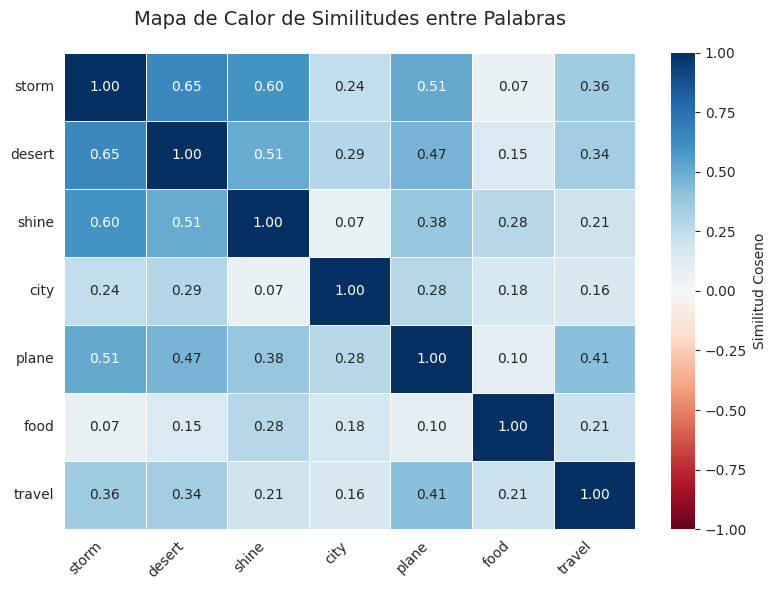

In [47]:
palabras_para_mapa = ['storm','desert','shine','city','plane', 'food', 'travel']
# Seleccionar subset
mapa_calor_similitudes(modelo, palabras_para_mapa)